# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "sparse-reg" #"prim-Nact-Ediv-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Nact_I,psi_Nact_H,psi_Nact_P,F0_Nact,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_Ediv_I,psi_Ediv_H,psi_Ediv_P,F0_Ediv,harm_pI,T_min_pI,harm_pS,max_pM_fold,T_pM_min,T_max_pI,T_pE_start,T_pE_max,max_pE_fold,min_pS,antigenicity_over_harm,T_pE_clear,harm_pI_noprotection,peff_protection,peff_toxicity,peff_utility
0,2.000000e-07,0.25,10000.0,1000.0,10000000.0,300.0,0.01,5000.0,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,1.047529e+07,0.0,0.000000,0.000000,0.000000,6.55,20.000000,0.00,1.000000,1.522926e+05,1.875061,-6.55,5.237645,0.000000,0.000000,0.000000
300,2.000000e-07,0.25,10000.0,1000.0,10000000.0,300.0,0.01,5000.0,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,1.047529e+07,0.0,0.000000,0.000000,0.000000,6.55,20.000000,0.00,1.000000,1.522926e+05,1.875061,-6.55,5.237645,0.000000,0.000000,0.000000
600,2.000000e-07,0.25,10000.0,1000.0,10000000.0,300.0,0.01,5000.0,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,1.047529e+07,0.0,0.000000,0.000000,0.000000,6.55,20.000000,0.00,1.000000,1.522926e+05,1.875061,-6.55,5.237645,0.000000,0.000000,0.000000
900,2.000000e-07,0.25,10000.0,1000.0,10000000.0,300.0,0.01,5000.0,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,1.047529e+07,0.0,0.000000,0.000000,0.000000,6.55,20.000000,0.00,1.000000,1.522926e+05,1.875061,-6.55,5.237645,0.000000,0.000000,0.000000
1200,2.000000e-07,0.25,10000.0,1000.0,10000000.0,300.0,0.01,5000.0,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,1.047529e+07,0.0,0.000000,0.000000,0.000000,6.55,20.000000,0.00,1.000000,1.522926e+05,1.875061,-6.55,5.237645,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93186299,2.000000e-07,1.25,1000000.0,1000.0,10000000.0,300.0,0.01,500000.0,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,6.595454e+06,0.0,58.281379,2.813333,0.000000,11.16,2.335067,12.00,1.000000,3.910226e+06,1.013798,0.84,3.298068,0.000341,0.000029,0.000311
93186599,2.000000e-07,1.25,1000000.0,1000.0,10000000.0,300.0,0.01,500000.0,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,6.595459e+06,0.0,60.154101,2.746667,0.000000,11.16,2.599800,11.51,1.000000,3.910216e+06,1.013798,0.35,3.298068,0.000338,0.000030,0.000308
93186899,2.000000e-07,1.25,1000000.0,1000.0,10000000.0,300.0,0.01,500000.0,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.595333e+06,0.0,68.368746,2.876667,0.000000,11.16,2.572367,12.14,1.036667,3.910331e+06,1.013798,0.98,3.298068,0.000401,0.000034,0.000367
93187199,2.000000e-07,1.25,1000000.0,1000.0,10000000.0,300.0,0.01,500000.0,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,6.592494e+06,0.0,320.189912,6.050000,3.979503,11.15,3.181167,11.79,3.350000,3.912842e+06,1.013798,0.64,3.298068,0.001821,0.000160,0.001661


In [3]:
# Define parameters
modules = ['$N \longrightarrow N^*$', '$N^* \longrightarrow E$', '$E \longrightarrow M$', '$E \longrightarrow E + E$']
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'$N \longrightarrow N^*$': [r for r in Nact_reg if np.std(infection_scenarios[0][r].values) > 0], 
              '$N^* \longrightarrow E$': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              '$E \longrightarrow M$': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              '$E \longrightarrow E + E$': [r for r in Ediv_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'$N \longrightarrow N^*$': [r for i, r in enumerate(param_names[-16:-12]) if  Nact_reg[i] in module_reg['$N \longrightarrow N^*$']], 
                     '$N^* \longrightarrow E$': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['$N^* \longrightarrow E$']],
                     '$E \longrightarrow M$': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['$E \longrightarrow M$']],
                     '$E \longrightarrow E + E$': [r for i, r in enumerate(param_names[-4:]) if  Ediv_reg[i] in module_reg['$E \longrightarrow E + E$']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Baseline"]) if np.std(infection_scenarios[0][[Nact_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [Ediv_reg[i]]].values) > 0]

reg = [r for r in Nact_reg + NE_reg + EM_reg + Ediv_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 10
fevals: 11
fevals: 13
fevals: 43


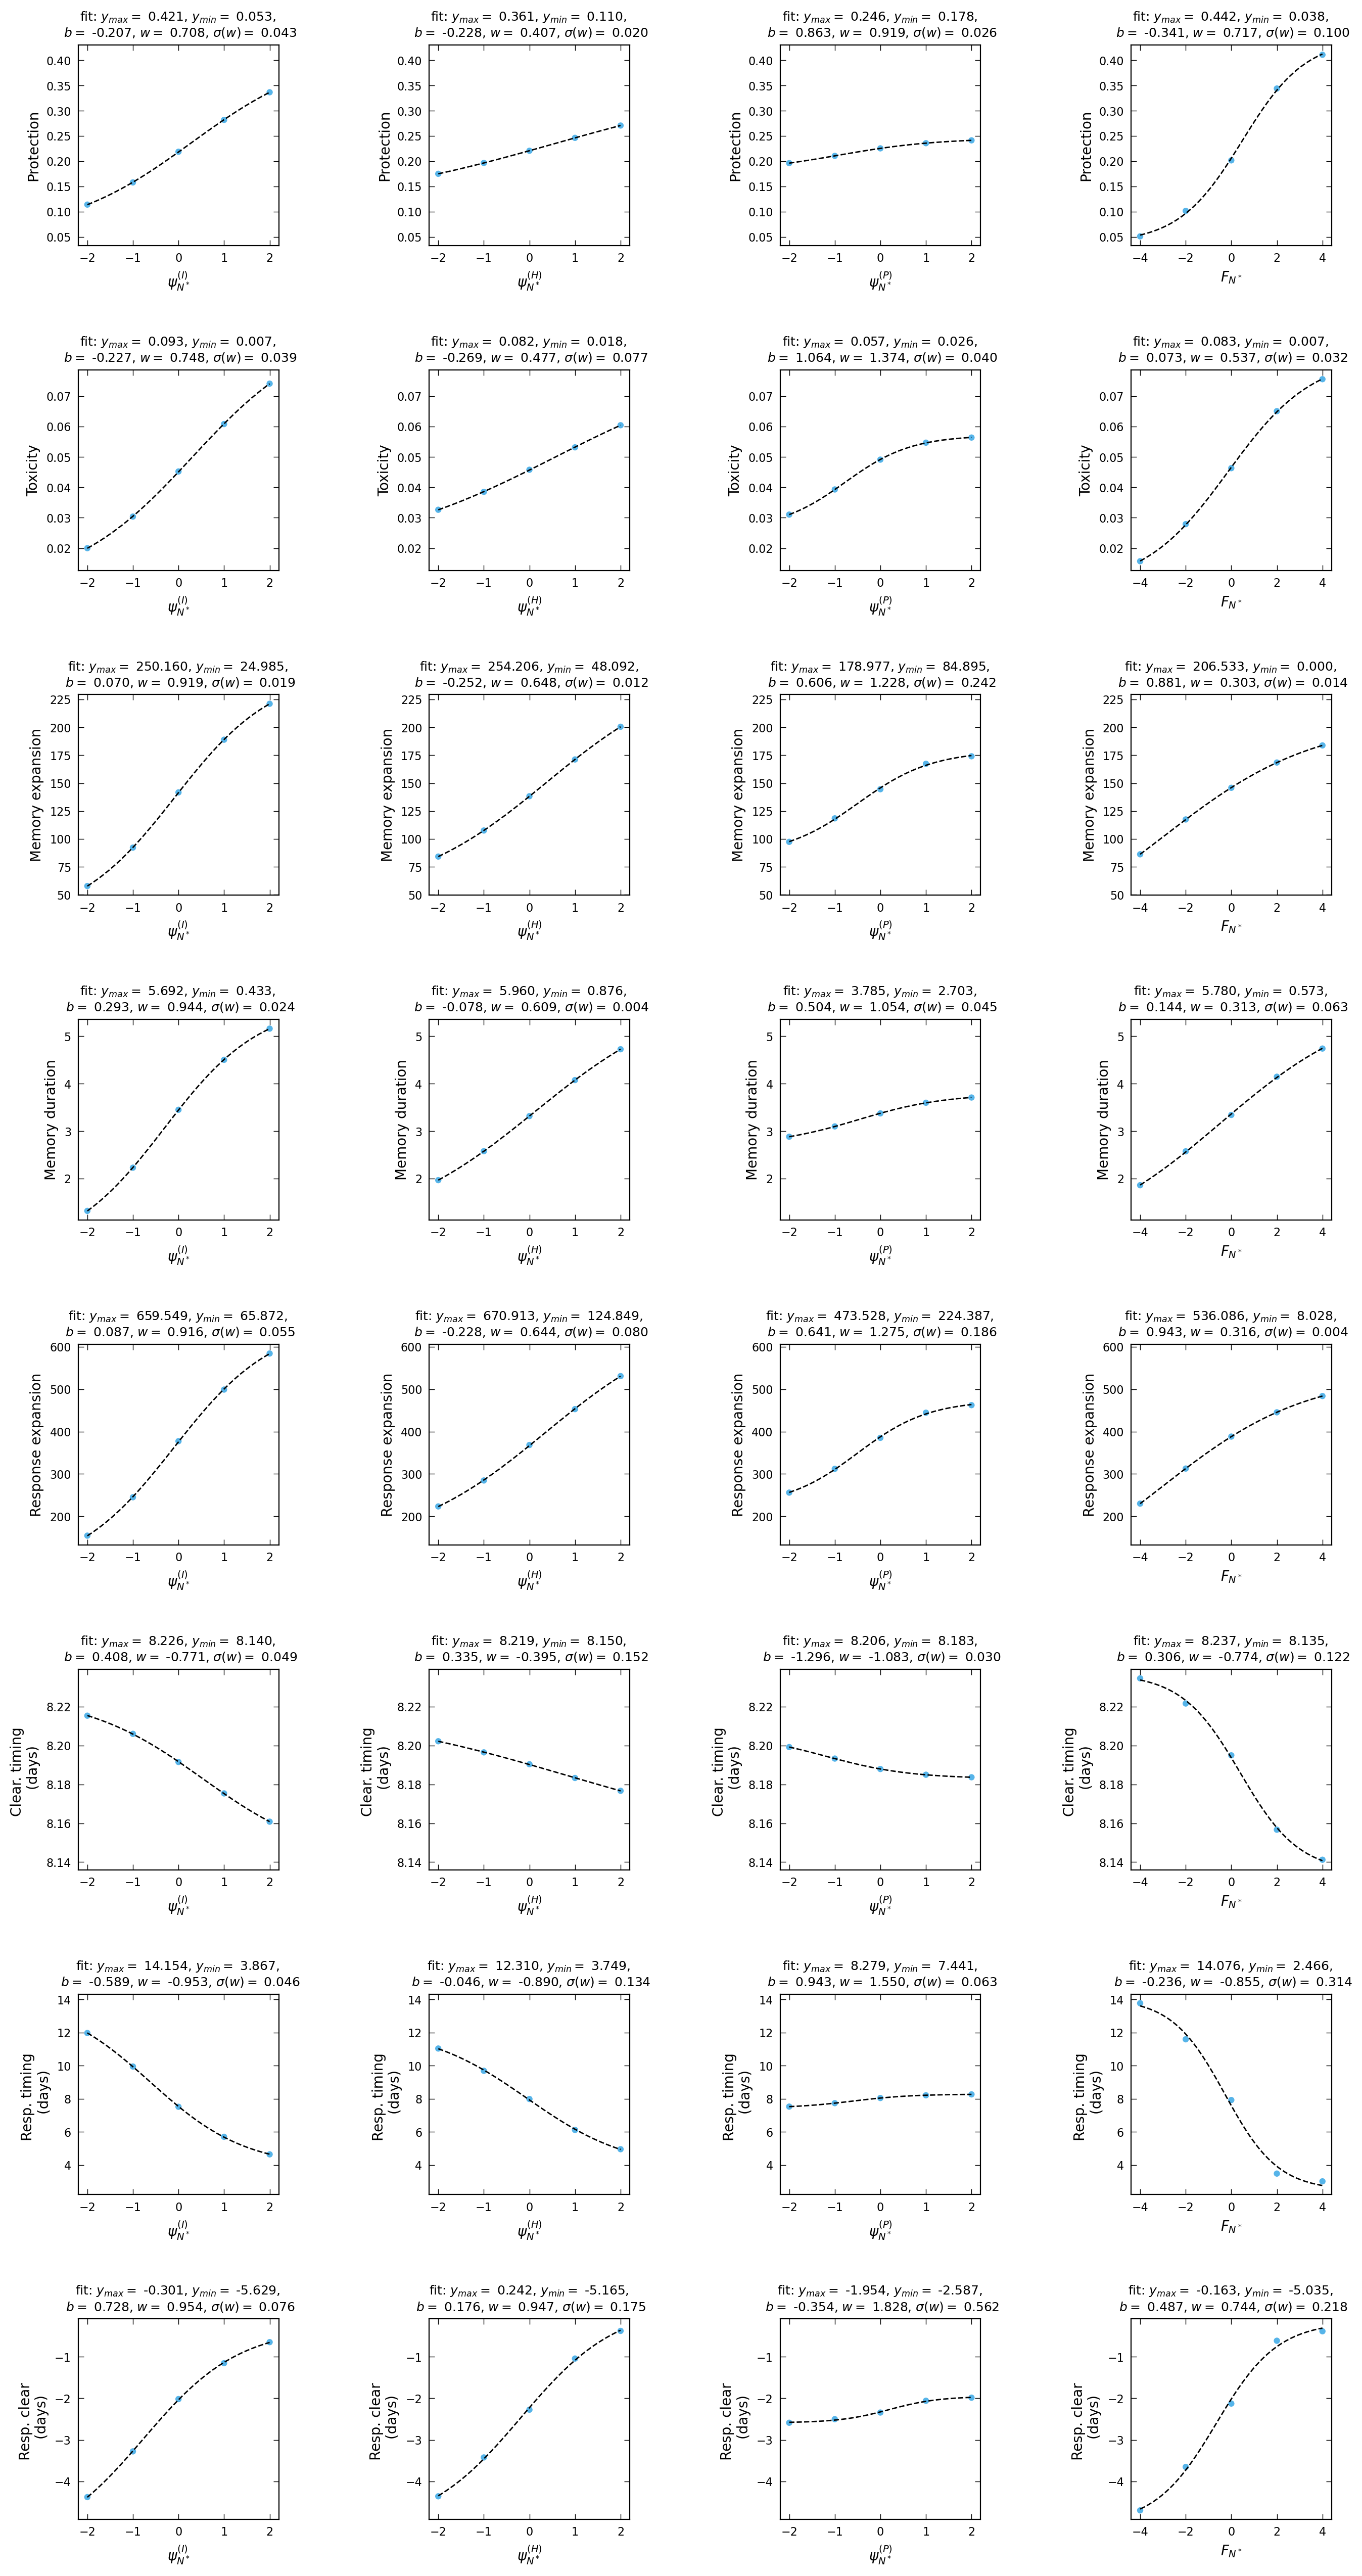

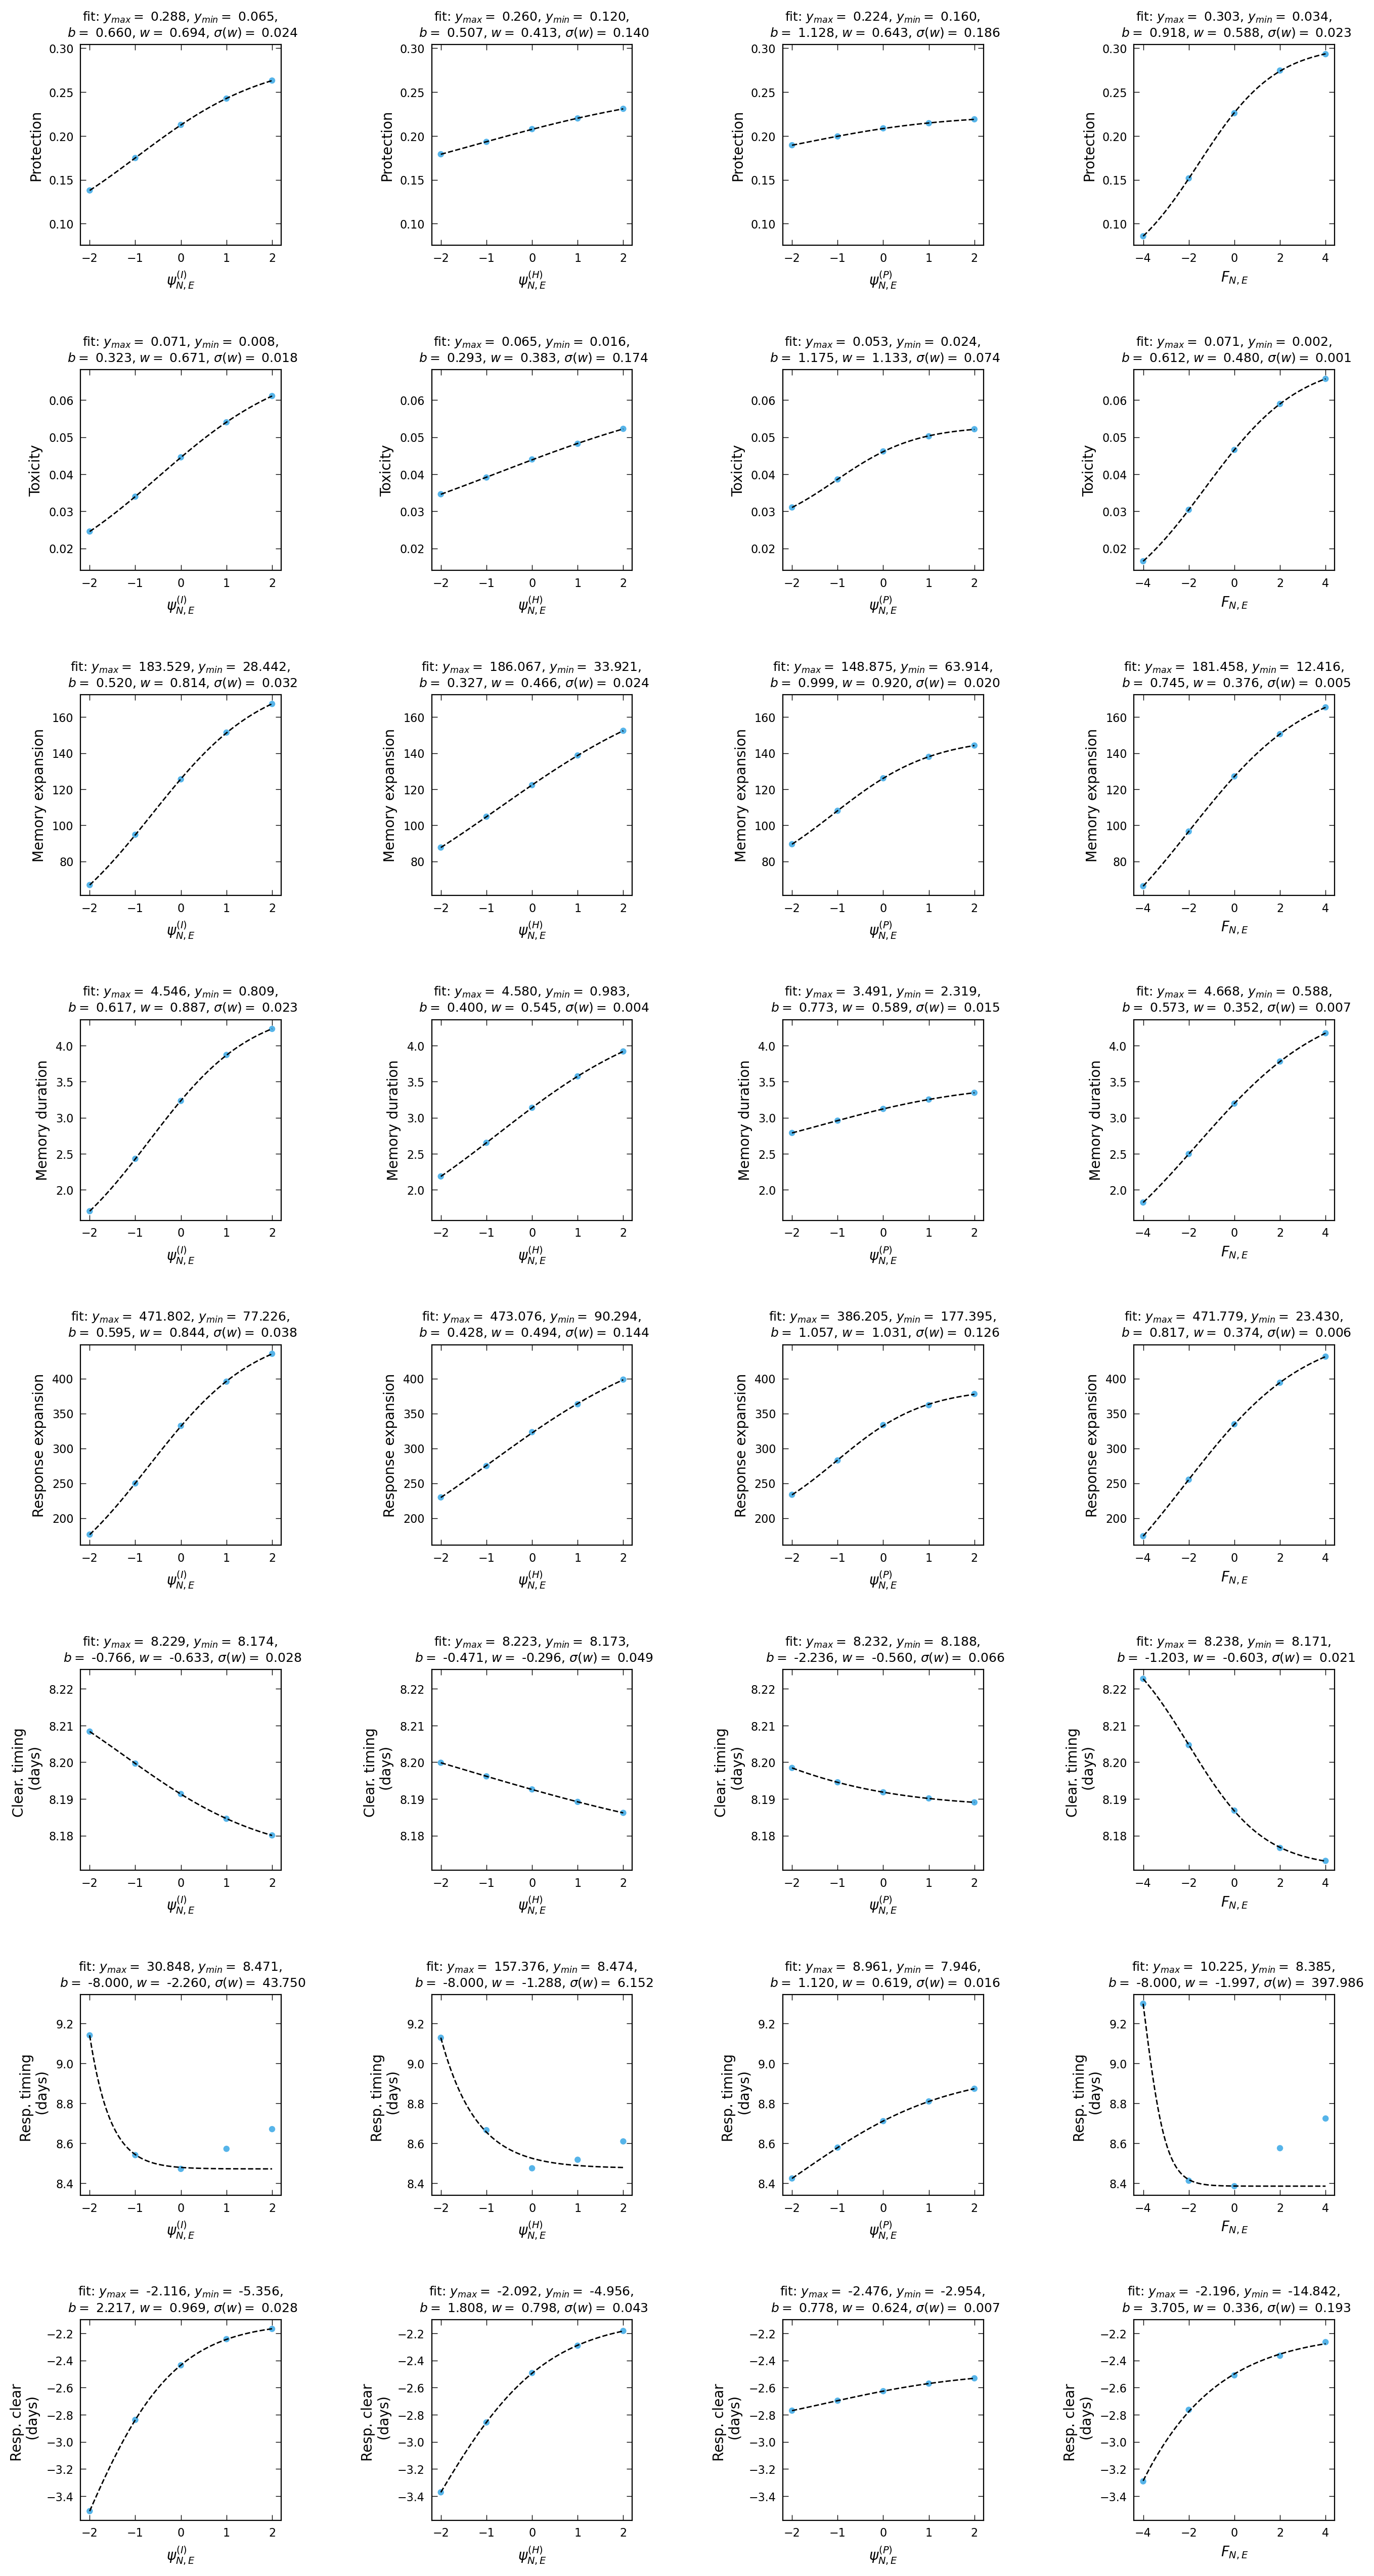

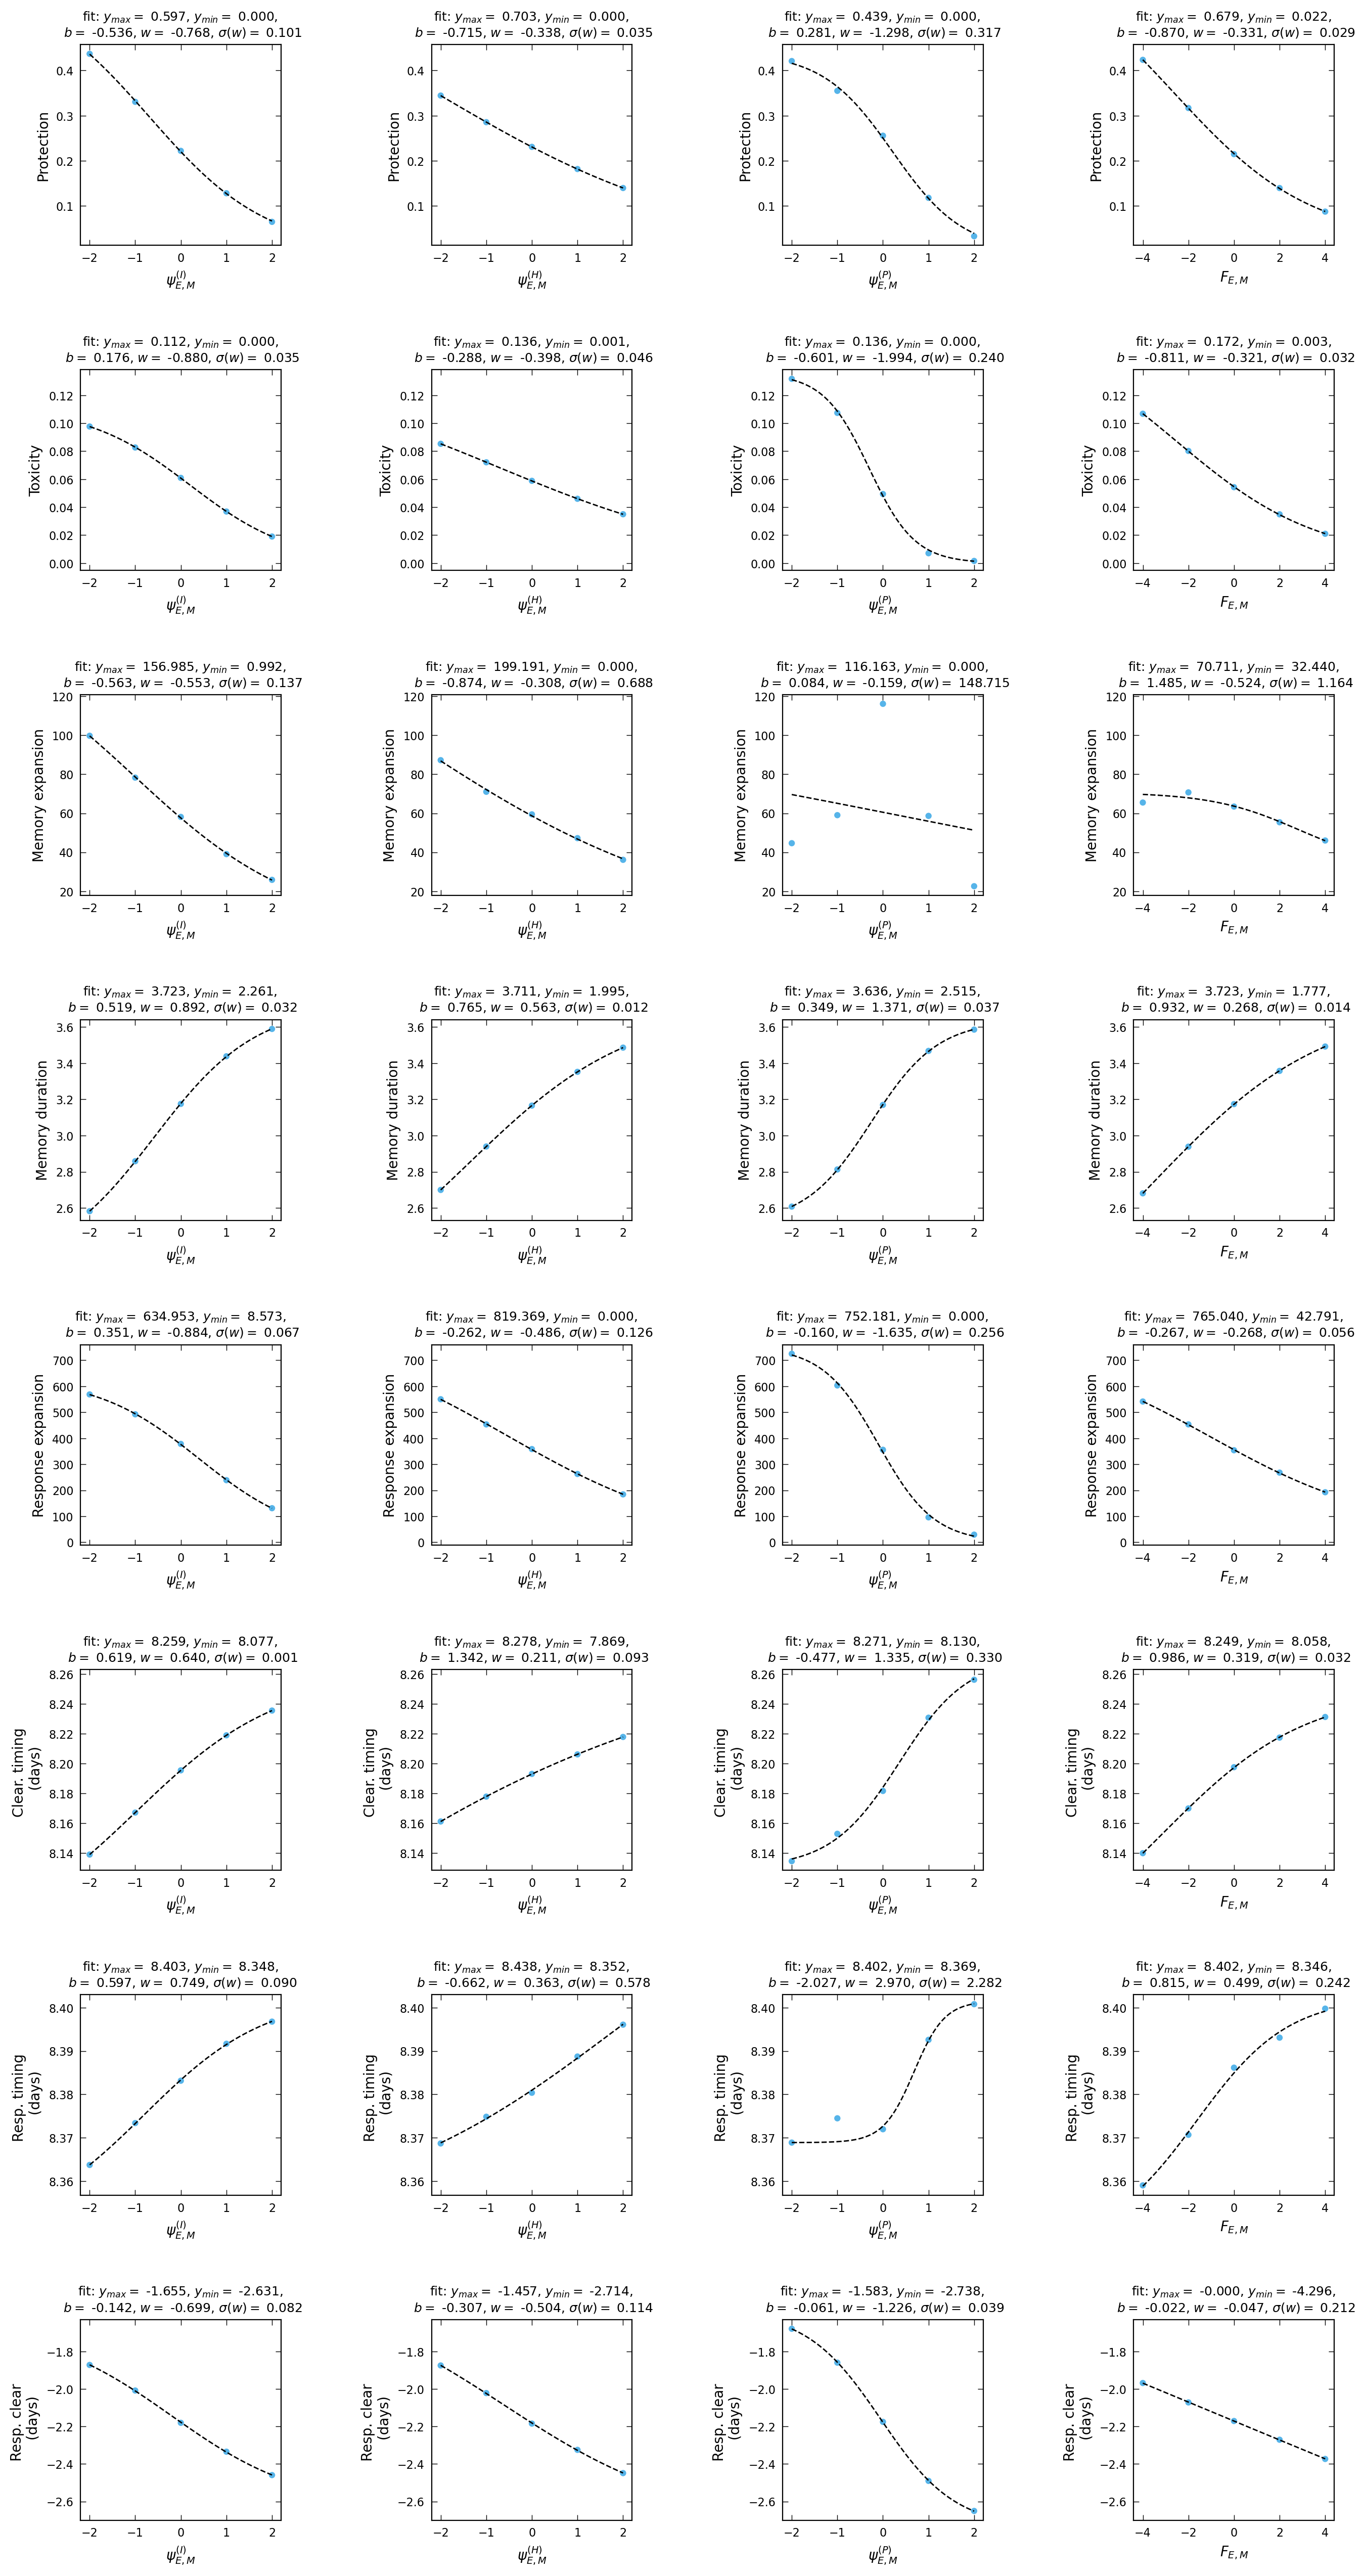

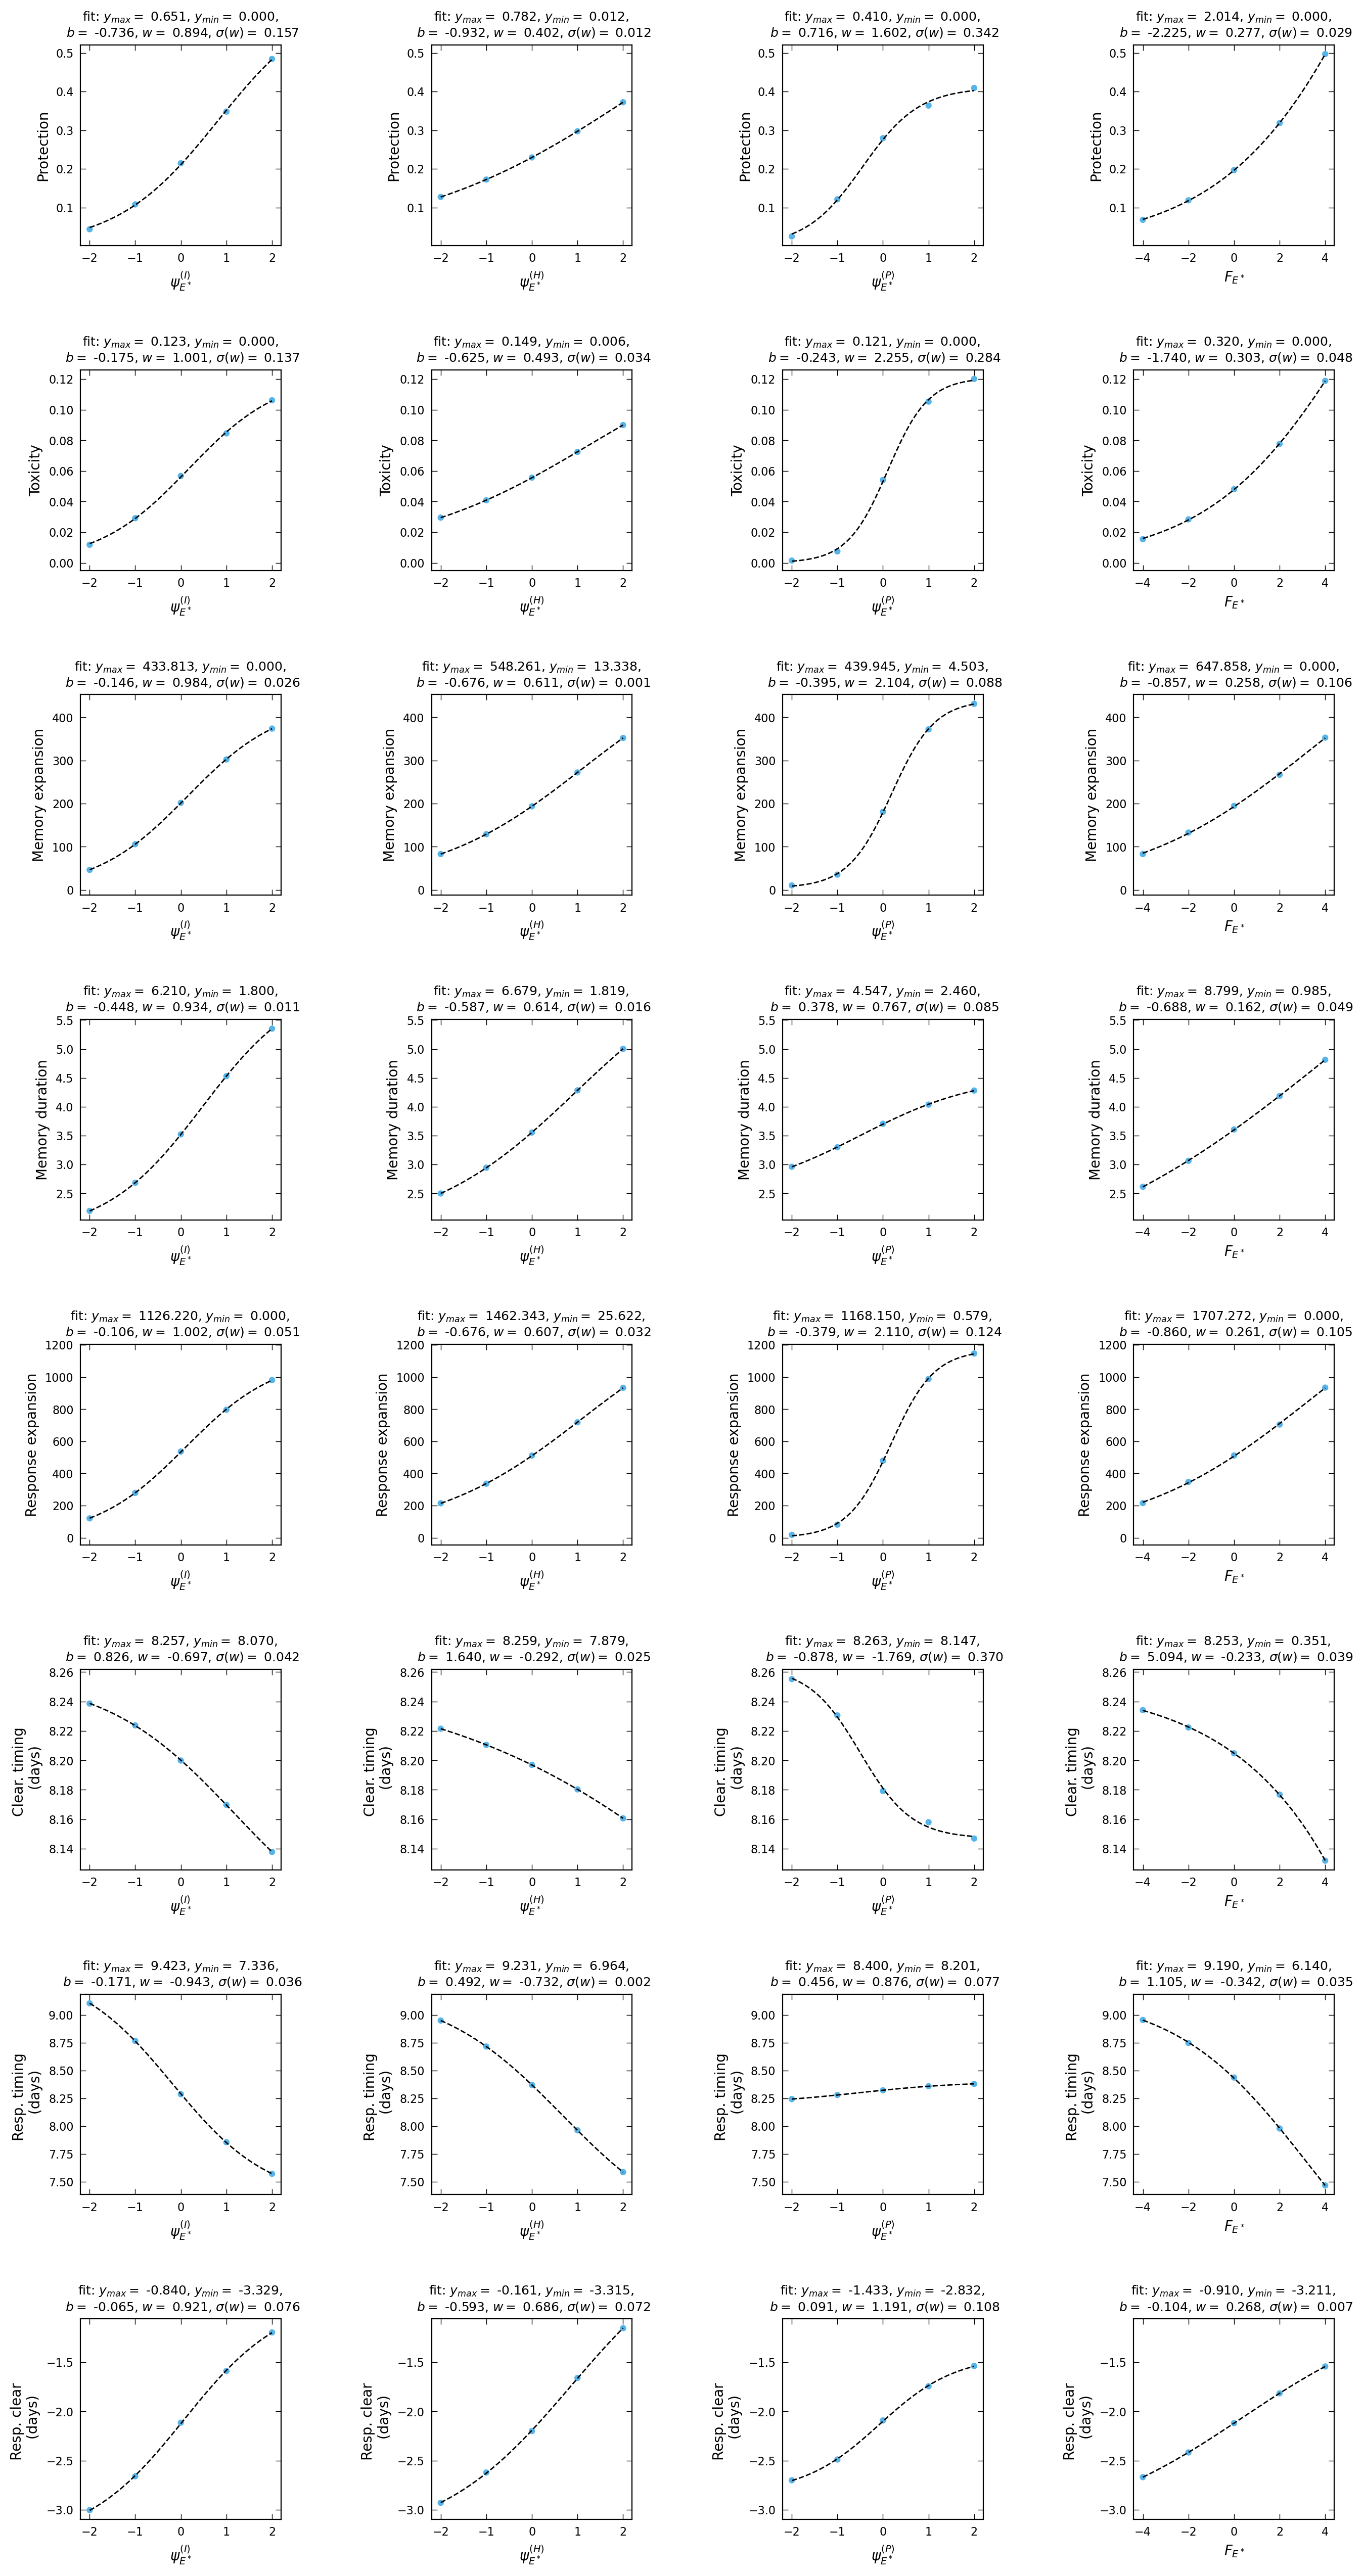

In [4]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[clustered_mean_df.K_EH == K_EH].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.1),
                                   method = 'trf', 
                                   bounds = ([np.max(data_mean[var].values), np.minimum(2*y_min, 0), -2*psi_max, -2*psi_max], [10*y_max if y_max > 0 else 0.0, np.min(data_mean[var].values), 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{max} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [5]:
# Regress Performance measures on regulation parameters
num_cpu = 150
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0 if y_min > 0.0 else y_min] + num_modules*[0.0] + len(variables)*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_min, np.minimum(5*y_min, 0)] + num_modules*[-3.0*psi_max] + len(variables)*[-3.0*psi_max], 
                                     [5*(y_max - y_min) if y_max > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1] + num_modules*[3.0*psi_max] + len(variables)*[3.0*psi_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), np.max(input[perf].values), np.min(input[perf].values), np.median(input[perf].values), i, rmse, y_std, input['harm_pI_noprotection'].values[0]])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), columns = ['y_max', 'y_min'] + [('intercept_' + j) for j in reg_bl] + variables + ['sigma_y_max', 'sigma_y_min'] + [('sigma_intercept_' + j) for j in reg_bl] + ['sigma_'+r  for r in variables] + vir_vars + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+'-'+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                               columns = ['y_max', 'y_min'] + [('intercept_' + j) for j in reg_bl] + variables + ['sigma_y_max', 'sigma_y_min'] + [('sigma_intercept_' + j) for j in reg_bl] + ['sigma_'+r  for r in variables] + vir_vars + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+'-'+'impact_data'+'.pkl')

In [6]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+'-'+'impact_data'+'.pkl')

In [31]:
# View result
perf = 3 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+'-'+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_max,y_min,intercept_F0_Nact,intercept_F0_NE,intercept_F0_EM,intercept_F0_Ediv,psi_Nact_I,psi_Nact_H,psi_Nact_P,F0_Nact,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_Ediv_I,psi_Ediv_H,psi_Ediv_P,F0_Ediv,sigma_y_max,sigma_y_min,sigma_intercept_F0_Nact,sigma_intercept_F0_NE,sigma_intercept_F0_EM,sigma_intercept_F0_Ediv,sigma_psi_Nact_I,sigma_psi_Nact_H,sigma_psi_Nact_P,sigma_F0_Nact,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_Ediv_I,sigma_psi_Ediv_H,sigma_psi_Ediv_P,sigma_F0_Ediv,d_I,K_IE,b_I,K_EH,S_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,antigenicity_over_harm
3,22.407780,2.275640e-19,1.721617,3.186908,6.506257,-1.023691,4.061774,2.287111,1.109660,1.291149,1.722546,0.820725,0.594444,0.620531,0.646090,0.426435,0.697183,0.277647,0.527337,0.322872,0.307625,0.207112,0.106075,0.007828,0.004165,0.007658,0.029322,0.043901,0.023772,0.015020,0.009843,0.006872,0.009946,0.006843,0.006267,0.003095,0.006602,0.005671,0.006855,0.002935,0.003451,0.002673,0.002620,0.001010,0.25,10000.000000,2.000000e-07,5000.0,10000000.0,4.013343,13.170107,0.0,3.297439,3.0,1.882694,4.213749,5.237645,1.875061
11,22.625942,5.084803e-22,1.730551,3.243779,6.401101,-1.142387,4.835311,1.304590,0.714539,1.317480,2.047070,0.388171,0.310672,0.624670,0.773827,0.229477,0.545826,0.304084,0.605714,0.161785,0.161342,0.202327,0.110649,0.007633,0.003990,0.007431,0.027263,0.047651,0.027704,0.010747,0.008715,0.006983,0.011005,0.005817,0.005711,0.003052,0.007233,0.005137,0.006156,0.003139,0.003754,0.002117,0.002116,0.001013,0.25,10000.000000,2.000000e-07,50000.0,10000000.0,4.076745,13.224320,0.0,3.413171,3.0,1.859885,4.268448,5.237645,2.875061
19,22.691318,1.183609e-28,1.684136,3.254819,6.250055,-1.202677,5.277890,0.421052,0.310671,1.340557,2.183517,0.118928,0.119384,0.631197,0.833711,0.074037,0.417742,0.322162,0.631904,0.046727,0.064408,0.199837,0.112353,0.007366,0.003945,0.007268,0.025407,0.049405,0.030506,0.008783,0.008598,0.006971,0.011440,0.005561,0.005561,0.003053,0.007485,0.004955,0.005678,0.003234,0.003866,0.001895,0.001912,0.001010,0.25,10000.000000,2.000000e-07,500000.0,10000000.0,4.061517,13.237245,0.0,3.337413,3.0,1.844467,4.291904,5.237645,3.875061
27,22.200508,1.338655e-24,1.736082,3.169373,6.453899,-1.030391,3.900734,2.628458,1.075117,1.337418,1.636090,0.948145,0.554985,0.623784,0.633997,0.475520,0.713924,0.282665,0.508868,0.358397,0.315662,0.209588,0.102781,0.007697,0.004017,0.007564,0.028617,0.042560,0.023430,0.016935,0.009769,0.007339,0.009525,0.007151,0.006123,0.003083,0.006512,0.005842,0.006896,0.002942,0.003340,0.002774,0.002624,0.001003,0.25,16681.005372,2.000000e-07,5000.0,10000000.0,3.986372,13.152131,0.0,3.249893,3.0,1.864372,4.195395,5.237645,1.534141
35,22.723428,7.343811e-22,1.720061,3.236984,6.374291,-1.208123,4.597251,1.422743,0.713168,1.325551,1.989112,0.453963,0.303832,0.626769,0.761834,0.258180,0.555561,0.307030,0.587755,0.180411,0.164516,0.202847,0.112015,0.007616,0.003959,0.007380,0.026892,0.048046,0.026225,0.011017,0.008494,0.006987,0.010718,0.005874,0.005656,0.003043,0.007151,0.005200,0.006188,0.003149,0.003661,0.002142,0.002101,0.001012,0.25,16681.005372,2.000000e-07,50000.0,10000000.0,4.073017,13.299657,0.0,3.422656,3.0,1.850571,4.261737,5.237645,2.352323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2363,10.432302,4.934556e-37,1.049005,1.149302,4.013486,-2.051980,2.036121,6.014543,0.867292,2.929927,0.464375,1.291972,0.336347,0.735596,0.401597,1.204883,1.523127,0.859487,0.971637,2.658467,0.881617,1.147521,0.014487,0.001571,0.003427,0.004971,0.005398,0.003115,0.012925,0.032044,0.009319,0.015053,0.004089,0.005493,0.003962,0.002269,0.006621,0.008762,0.009903,0.004716,0.004596,0.008965,0.004418,0.003567,1.25,59

#### Check the model goodness of the fit
The model does a pretty good job as most of the $R^2$ values are above 0.80.

Text(0, 0.5, 'Counts')

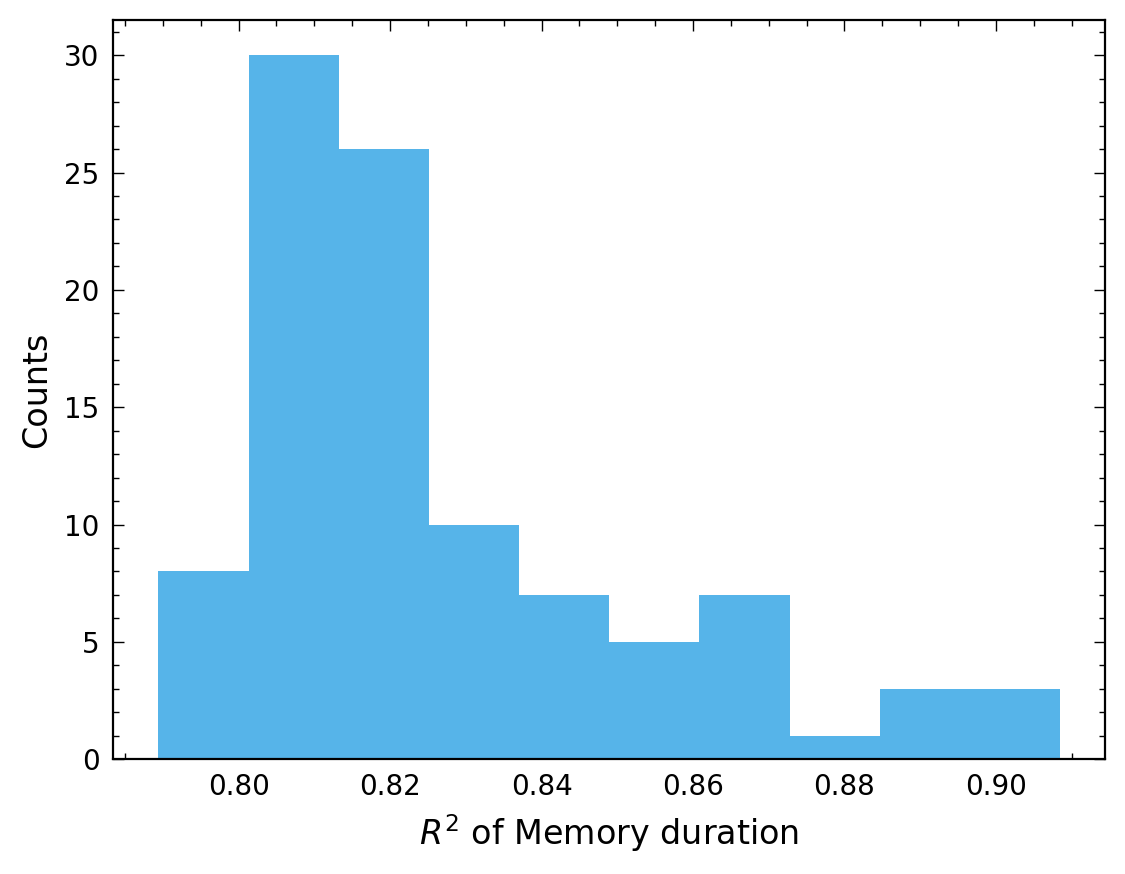

In [32]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

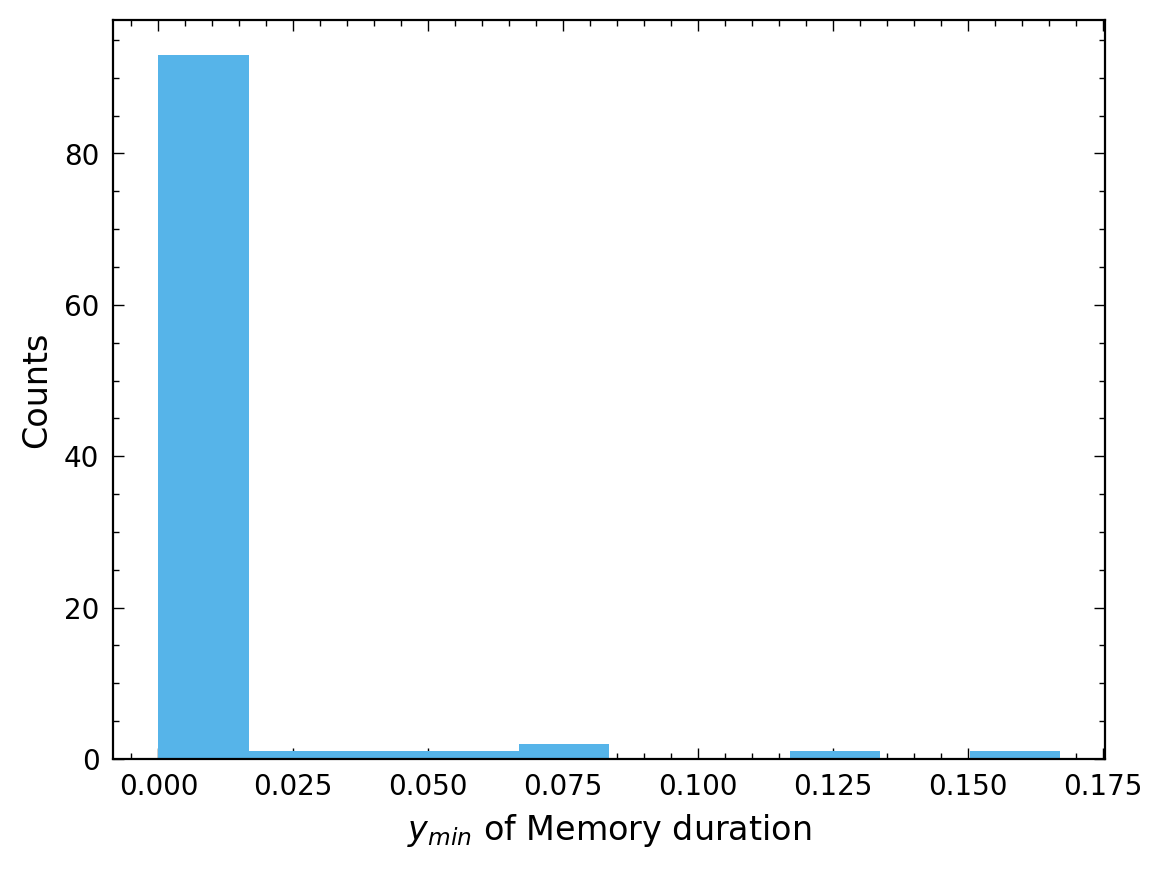

In [33]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

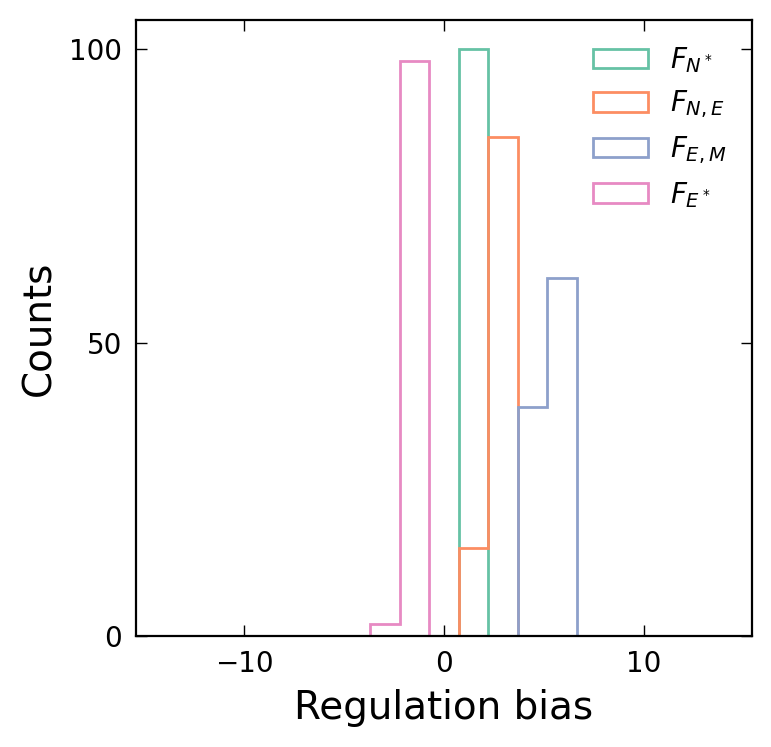

In [34]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(reg_bl):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 20), histtype = 'step', label = reg_bl_label[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias", fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

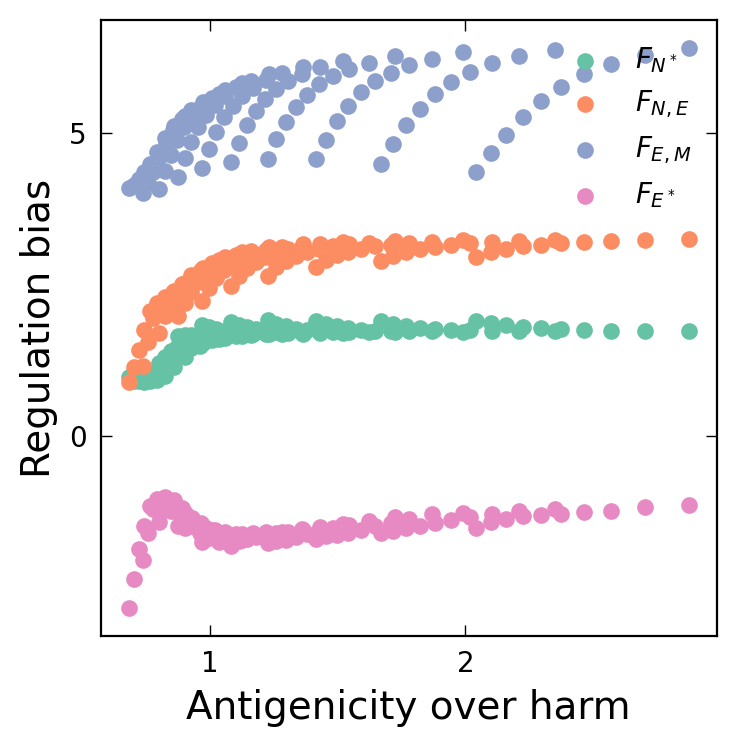

In [35]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(reg_bl):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = reg_bl_label[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

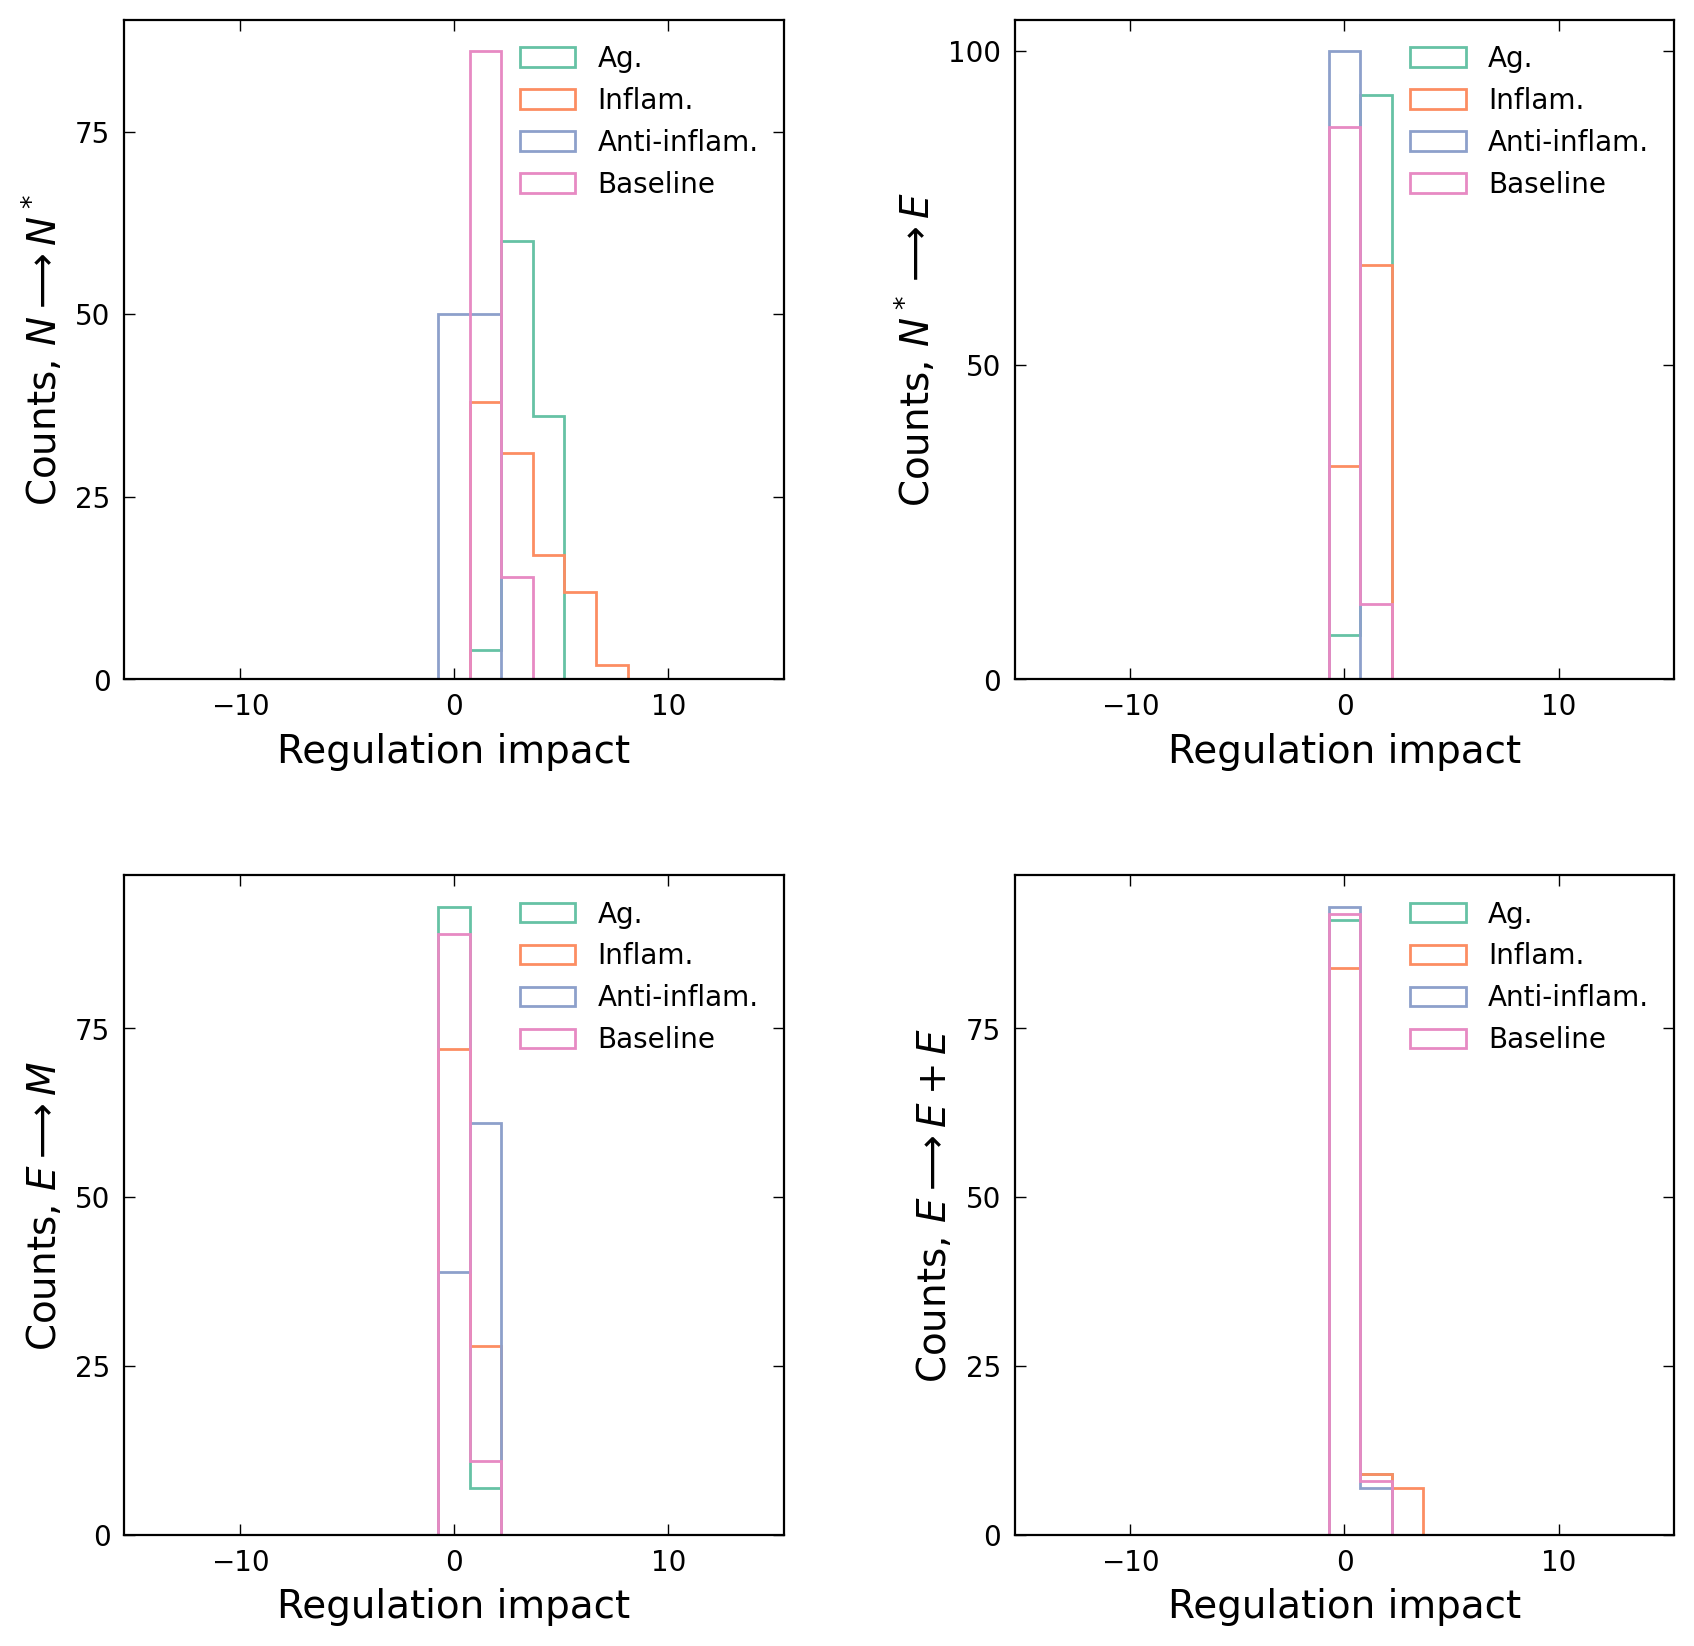

In [36]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 20), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+modules[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")